In [1]:
print("Lohith V P -  24BAD064")
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

Lohith V P -  24BAD064


In [ ]:
#loading the dataset
df = pd.read_csv("u.data", sep="\t", names=["user", "item", "rating", "timestamp"])
df.head()

,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
#using pivot to create user-item matrix
user_item_matrix = df.pivot(index="user", columns="item", values="rating")
user_item_matrix.head()

item,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Applying SVD
matrix_filled = user_item_matrix.fillna(0)
svd = TruncatedSVD(n_components=50)

U = svd.fit_transform(matrix_filled)
Sigma = svd.singular_values_
VT = svd.components_

In [ ]:
# Reconstruct the matrix
reconstructed = np.dot(U, VT)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)

reconstructed_df.head()

item,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user,,,,,,,,,,,,,,,,,,,,,
1,5.017682,2.751909,1.658356,2.862603,2.063792,1.459854,4.411527,0.795790,2.045778,2.491759,...,0.024739,-0.024086,-0.064226,-0.042817,0.030758,0.003439,0.010316,0.006877,0.042651,0.078231
2,2.299921,0.075926,-0.157767,0.408265,0.213339,0.498697,0.612696,0.687792,2.148237,0.714159,...,0.018723,-0.026980,-0.029651,-0.019767,0.004274,0.005291,0.015873,0.010582,0.024629,-0.038936
3,0.695274,-0.167028,-0.111281,-0.276220,0.002520,-0.015661,-0.198679,0.260318,-0.187644,0.370108,...,-0.006165,-0.013541,0.055670,0.037113,-0.008295,0.015287,0.045862,0.030574,0.001773,0.005347
4,0.478090,-0.369441,0.104599,-0.016518,-0.016589,-0.026109,0.359479,-0.218143,0.016456,0.012379,...,0.009255,-0.006455,-0.010403,-0.006936,0.006119,0.006596,0.019789,0.013193,-0.009325,-0.017161
5,4.003768,1.898665,0.170272,1.228337,0.698521,0.140981,1.779515,0.689032,0.002732,0.794193,...,-0.012017,-0.044434,-0.001329,-0.000886,-0.060768,-0.004411,-0.013234,-0.008823,-0.044423,-0.029327


In [22]:
# Convert to arrays
actual = user_item_matrix.values
predicted = reconstructed_df.values

# Create mask for non-missing values
mask = ~np.isnan(actual)

# Apply mask properly
actual_filtered = actual[mask]
predicted_filtered = predicted[mask]

# Compute metrics
rmse = np.sqrt(mean_squared_error(actual_filtered, predicted_filtered))
mae = mean_absolute_error(actual_filtered, predicted_filtered)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.859822337850259
MAE: 1.5426355217358871


In [ ]:
# Function to recommend items for a user
def recommend(user_id, n=5):
    user_ratings = reconstructed_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    
    recommendations = user_ratings.drop(already_rated)
    return recommendations.sort_values(ascending=False).head(n)

recommend(1, 5)

item
732    3.162971
423    2.816775
385    2.631112
403    2.580863
474    2.573464
Name: 1, dtype: float64

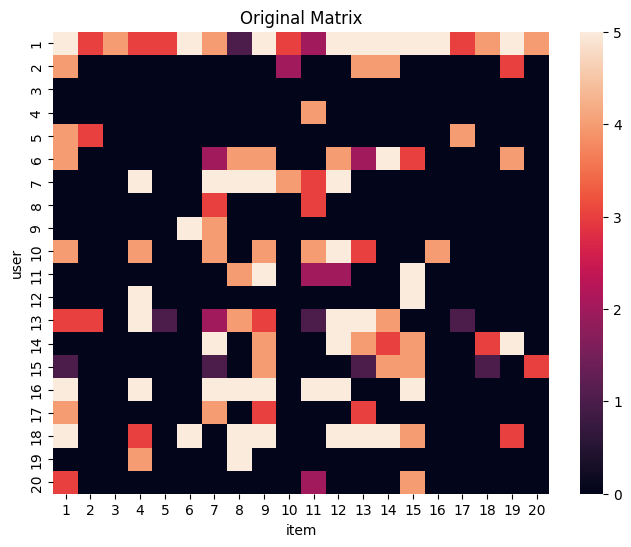

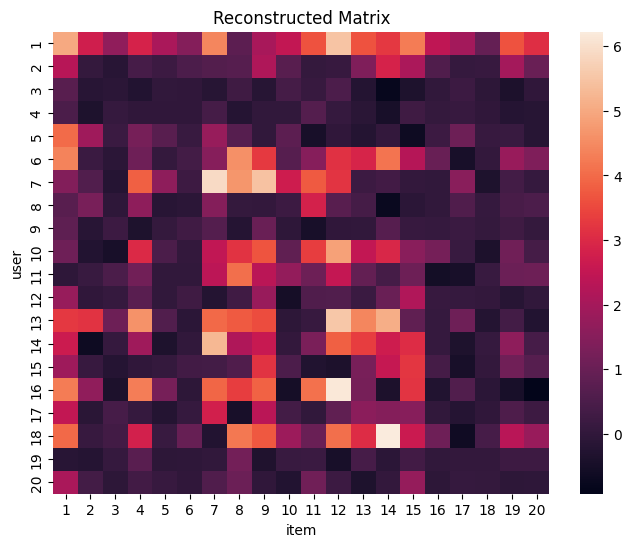

In [ ]:
# Visualize original vs reconstructed matrix
plt.figure(figsize=(8,6))
sns.heatmap(matrix_filled.iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()